# **Assignment 1: House Prices Data Preprocessing**

**Name**: Maram Wael Amassi

**Course**: Machine Learning

**Instructor**: Ibrahim O. Kaware

**Objective**:To apply comprehensive data preprocessing steps on the "House Prices"  dataset to prepare it for regression modeling.


# **<font color="green"> 1. Data Retrieval </font>**

  In this section, we load the dataset and perform an initial inspection to understand its structure and memory footprint.

In [ ]:
# Import Libraries

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
import plotly.express as px
from scipy import stats
from sklearn.preprocessing import LabelEncoder

# Display all the columns of dataframe
pd.pandas.set_option('display.max_columns', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


essential libraries needed for data manipulation.

pandas is used for handling datasets (DataFrames).
numpy is used for numerical operations.

In [ ]:
# Load training data
train = pd.read_csv("/content/drive/MyDrive/datasets/train.csv")

# Load testing data
test = pd.read_csv("/content/drive/MyDrive/datasets/test.csv")

# shape helps us understand the size of the dataset (rows, columns)
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Train Shape: (1460, 81)
Test Shape: (1459, 80)



# **<font color="green"> Data Inspection </font>**

In [ ]:

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


The training dataset contains the target variable (SalePrice), while the test dataset does not

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

understand:

Data types of each column

Missing values

Memory usage

This is important before cleaning and preprocessing

In [ ]:
# Reasoning:
# Real-world datasets like "House Prices" can be memory-intensive.
# We optimize memory in two ways:
# 1. Downcasting numeric types (float/int) to reduce bit-size without losing data.
# 2. Converting 'object' strings into 'category' types, which is more efficient for repeated labels.

def optimize_memory(df):
    for col in df.columns:
        # Step 1: Optimize Numbers (Your Doctor's implicit requirement)
        if df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')

        # Step 2: Your Brilliant Step (Converting objects to categories)
        elif df[col].dtype == 'object':
            df[col] = df[col].astype('category')

    return df

# Applying the optimized function to both datasets
train = optimize_memory(train)
test = optimize_memory(test)

print("Memory management optimized by downcasting numbers and converting objects to categories.")


Memory management optimized by downcasting numbers and converting objects to categories.


In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#The Id column does not provide useful information for prediction.
id="fix2"
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

In [ ]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **<font color="green"> 2.Data Cleaning  </font>**

We handle missing values and remove outliers that might negatively affect the model's performance

In [ ]:
#Missing Values Analysis
missing = train.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


We calculate the number of **missing values** in each column and display only columns that contain missing data.
This helps us decide **how to handle them.**

Percentage of missing values per feature:
LotFrontage: 17.74%
Alley: 93.77%
MasVnrType: 59.73%
MasVnrArea: 0.55%
BsmtQual: 2.53%
BsmtCond: 2.53%
BsmtExposure: 2.6%
BsmtFinType1: 2.53%
BsmtFinType2: 2.6%
FireplaceQu: 47.26%
GarageType: 5.55%
GarageYrBlt: 5.55%
GarageFinish: 5.55%
GarageQual: 5.55%
GarageCond: 5.55%
PoolQC: 99.52%
Fence: 80.75%
MiscFeature: 96.3%


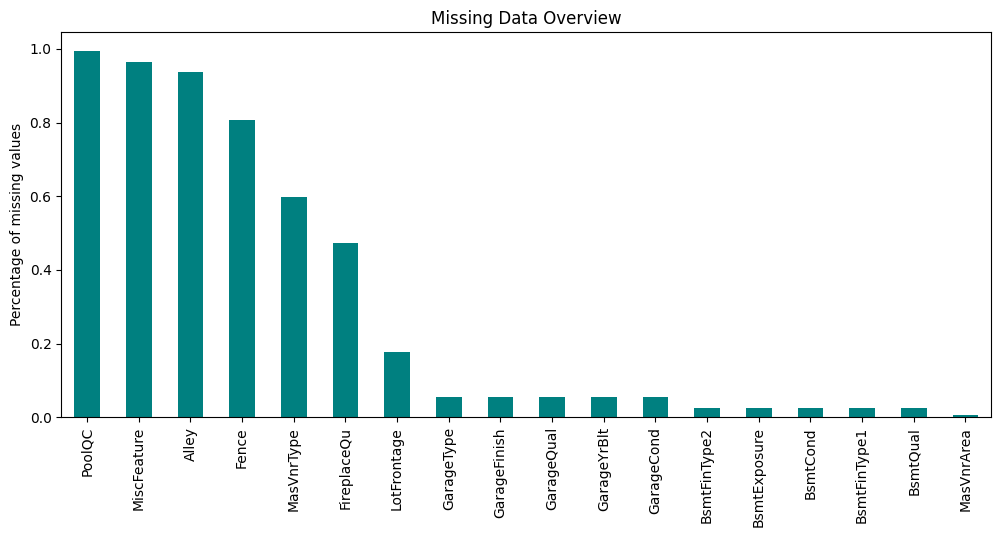

In [ ]:
# Reasoning: We need to identify which features require imputation or removal.
features_with_na = [features for features in train.columns if train[features].isnull().sum() > 1]

print("Percentage of missing values per feature:")
for feature in features_with_na:
    percentage = np.round(train[feature].isnull().mean() * 100, 2)
    print(f"{feature}: {percentage}%")

# --- Step 3: Visualizing Missing Values (Enhancement for Doctor's requirements) ---
# Reasoning: Visual representation helps in deciding the strategy for each feature.
plt.figure(figsize=(12, 5))
train[features_with_na].isnull().mean().sort_values(ascending=False).plot.bar(color='teal')
plt.ylabel('Percentage of missing values')
plt.title('Missing Data Overview')
plt.show()

 **Since they are many missing values,we need to find the relationship**

**between missing values and Sales Price.**

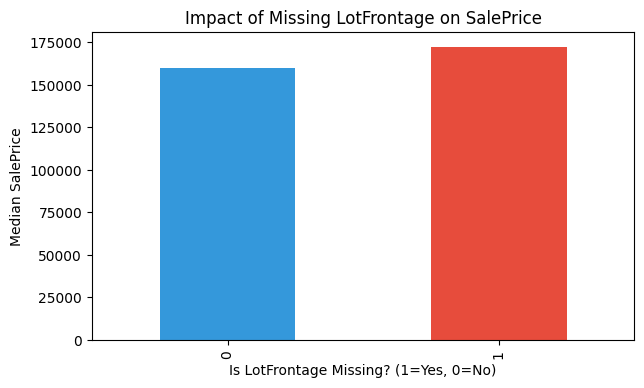

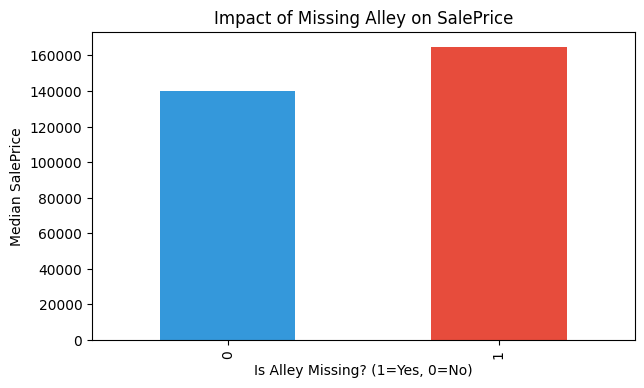

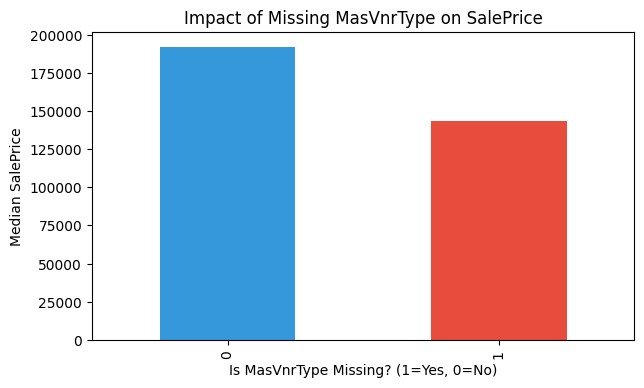

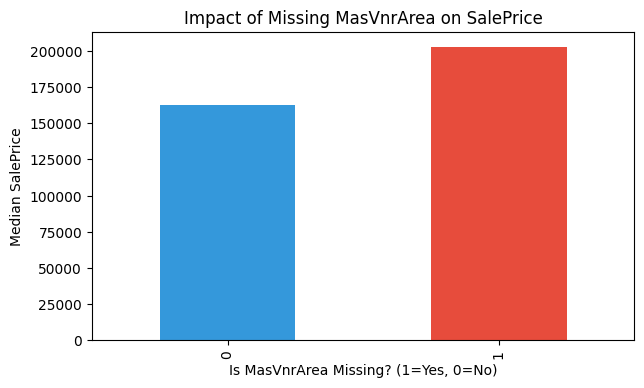

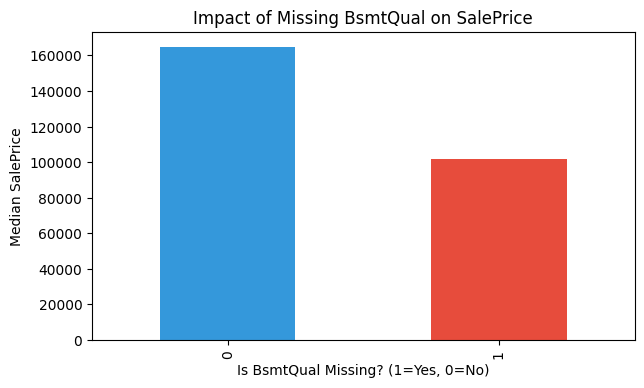

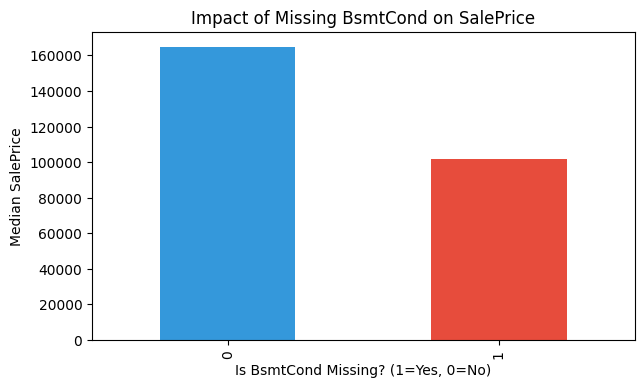

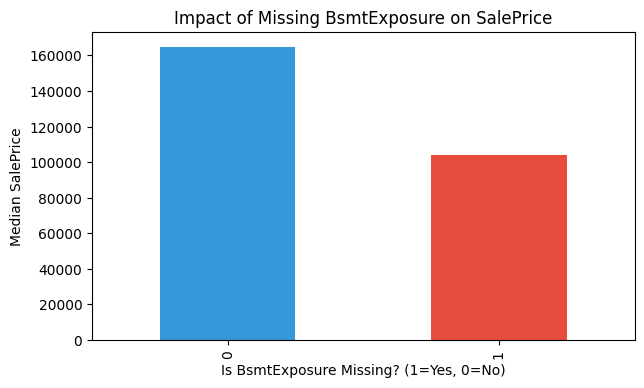

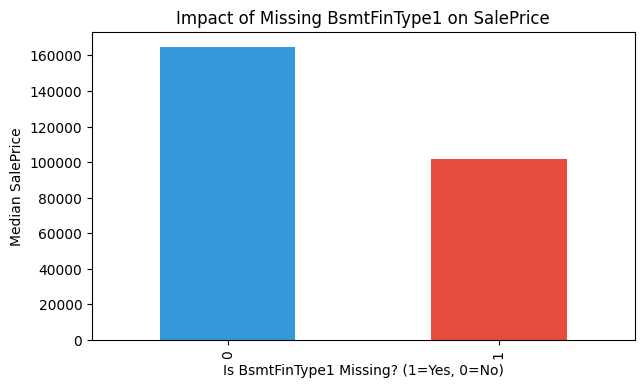

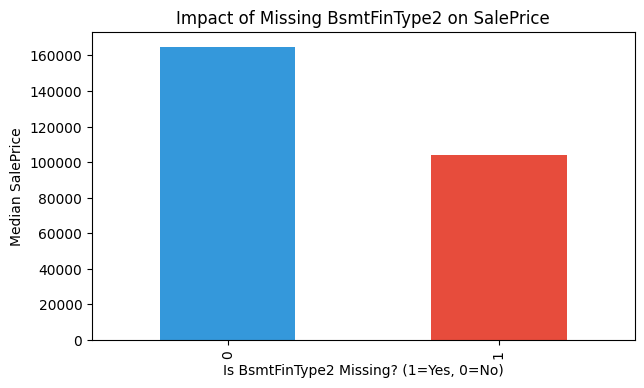

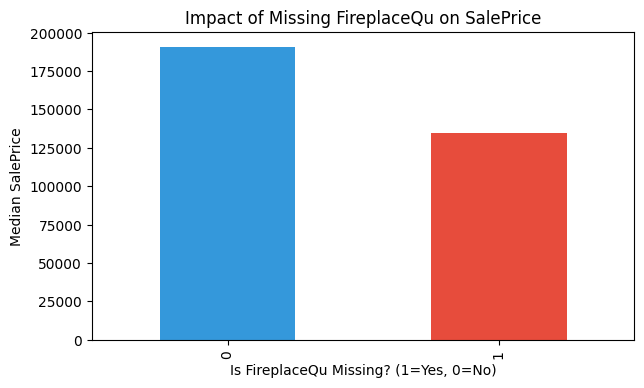

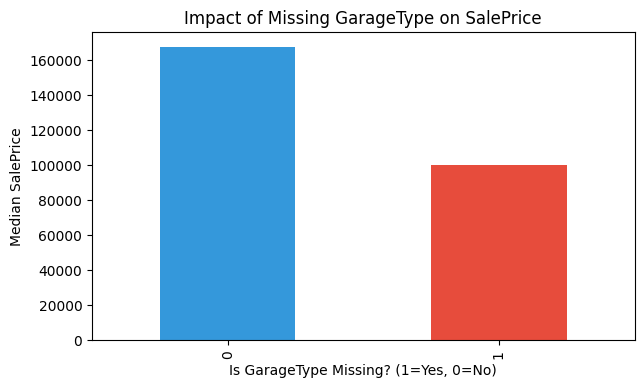

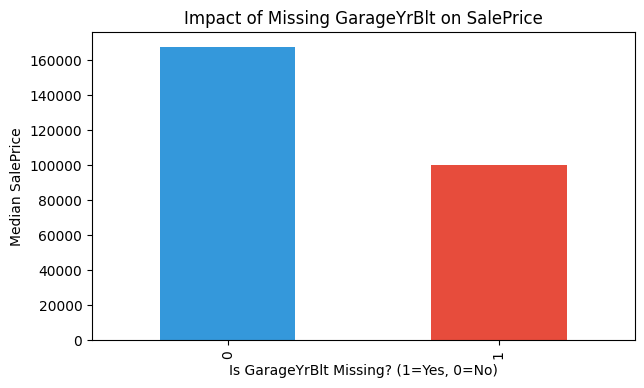

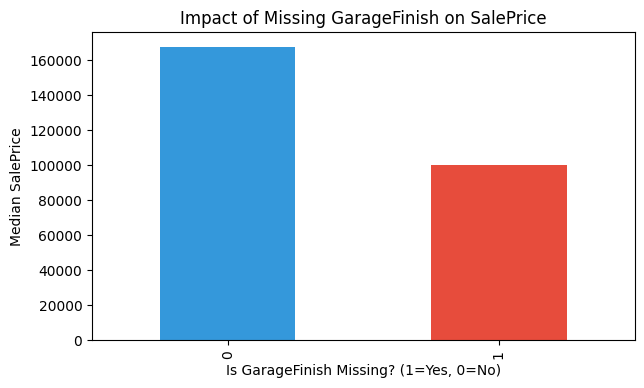

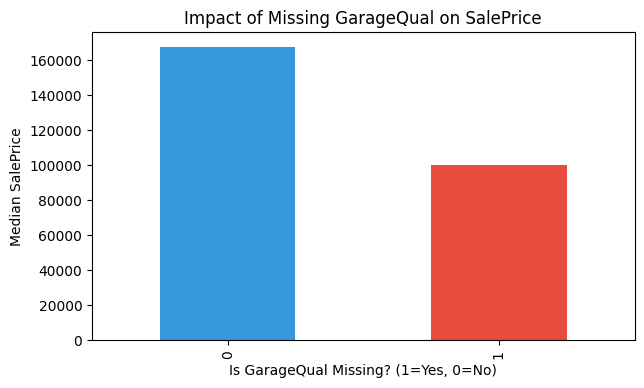

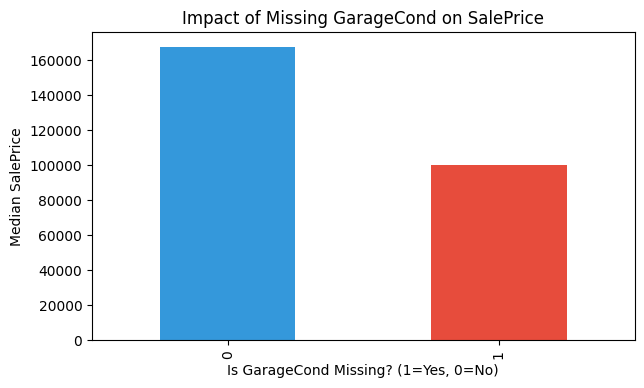

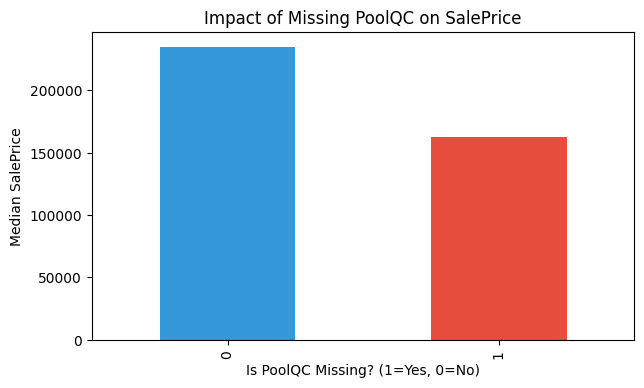

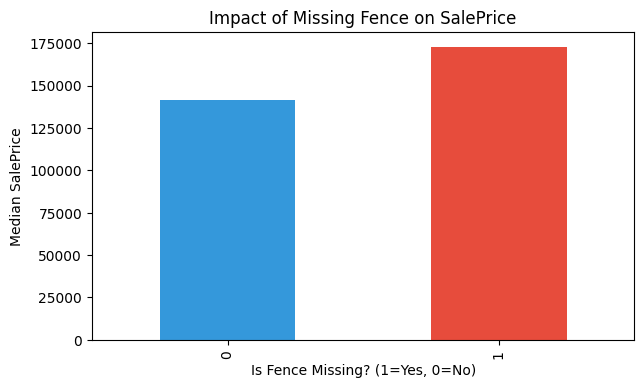

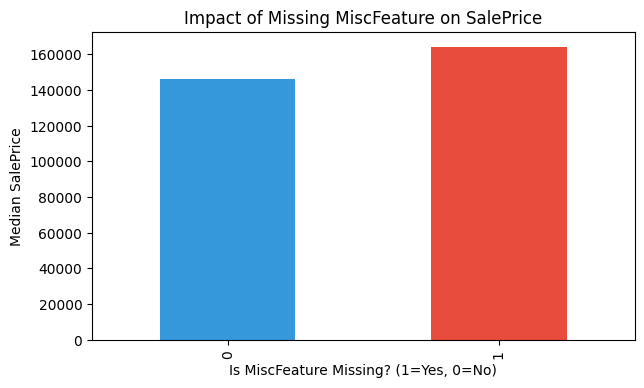

In [ ]:
# Analyzing the Relationship between Missing Values and Sales Price ---
# Reasoning:
# We want to check if the absence of information (NaN) has a specific impact on the house price.
# For example, if a house doesn't have a 'Pool', does its price differ significantly from others?
# We create a binary variable (1 if missing, 0 if present) and compare median SalePrices.

for feature in features_with_na:
    data = train.copy()

    # Create a dummy variable: 1 if missing, 0 otherwise
    data[feature] = np.where(data[feature].isnull(), 1, 0)

    # Compare median SalePrice for missing vs present data
    # Using Median because it is more robust to outliers than the Mean
    plt.figure(figsize=(7, 4))
    data.groupby(feature)['SalePrice'].median().plot.bar(color=['#3498db', '#e74c3c'])
    plt.title(f'Impact of Missing {feature} on SalePrice')
    plt.xlabel(f'Is {feature} Missing? (1=Yes, 0=No)')
    plt.ylabel('Median SalePrice')
    plt.show()


Here With the relation between the missing values and the dependent variable is clearly visible.So We need to replace these nan values with something meaningful which we will do in the Feature Engineering section

From the above dataset some of the features like Id is not required

In [ ]:
# Check total number of houses before and after processing
# Reasoning: To keep track of the dataset size and verify if any rows were dropped during cleaning.

print("Total number of Houses in training set: {}".format(len(train)))
print("Total number of Houses in test set: {}".format(len(test)))

Total number of Houses in training set: 1460
Total number of Houses in test set: 1459


In [ ]:
# Separating Features by Data Type ---
# Reasoning:
# Different types of data require different cleaning and encoding strategies.
# Numerical data will be analyzed for outliers and correlation.
# Categorical data will be analyzed for frequency and then encoded.

# Identify numerical features (excluding the Target: SalePrice)
numerical_features = [f for f in train.columns if train[f].dtypes != 'category' and f != 'SalePrice']

# Identify categorical features (already converted to 'category' type in Step 1)
categorical_features = [f for f in train.columns if train[f].dtypes == 'category']

print(f'Number of Numerical variables: {len(numerical_features)}')
print(f'Number of Categorical variables: {len(categorical_features)}')

# Visualizing the first few rows of numerical data to ensure correctness
train[numerical_features].head()


Number of Numerical variables: 36
Number of Categorical variables: 43


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008


# **Missing Value Analysis (The 0/1 Logic - Krish Naik Style)**

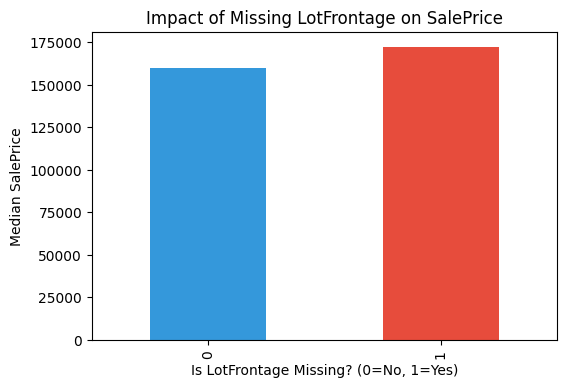

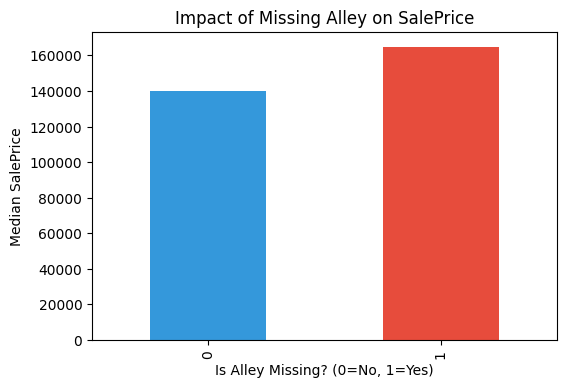

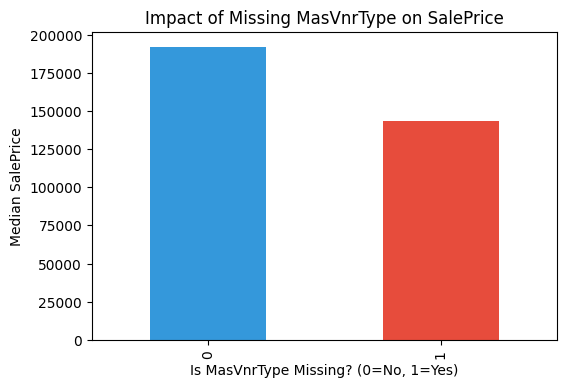

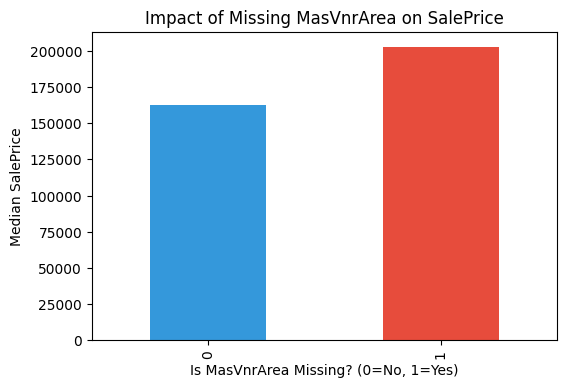

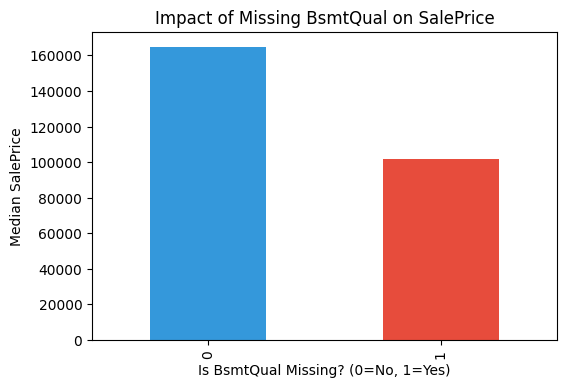

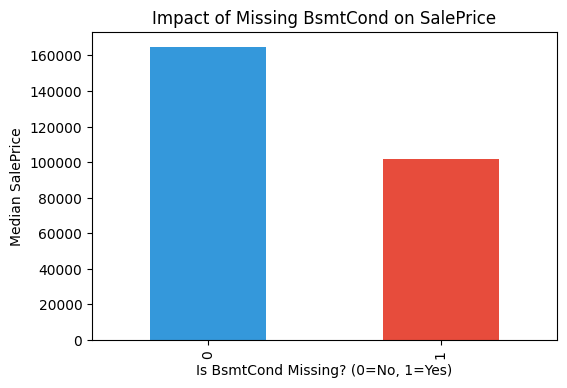

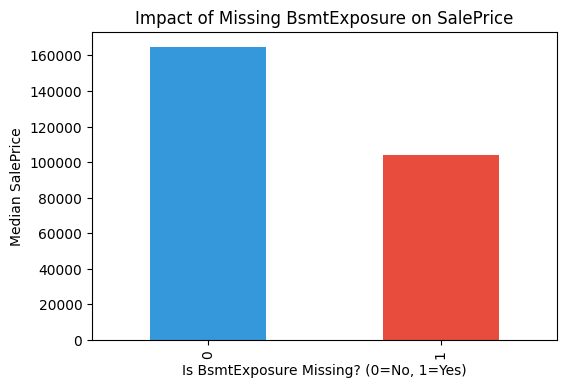

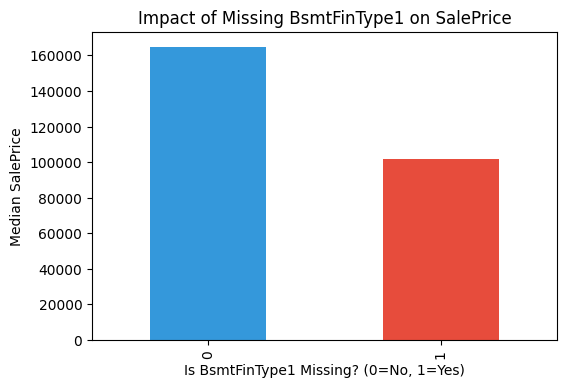

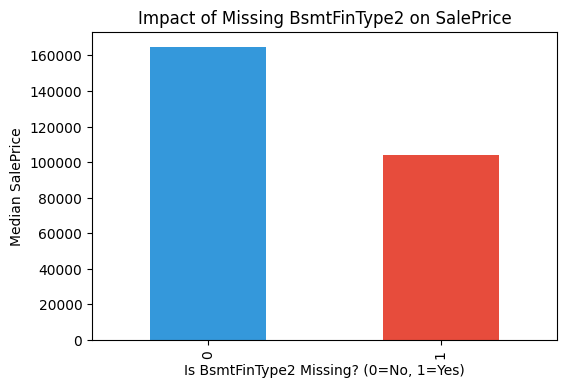

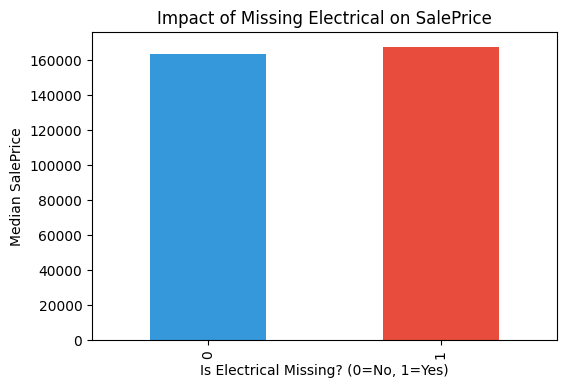

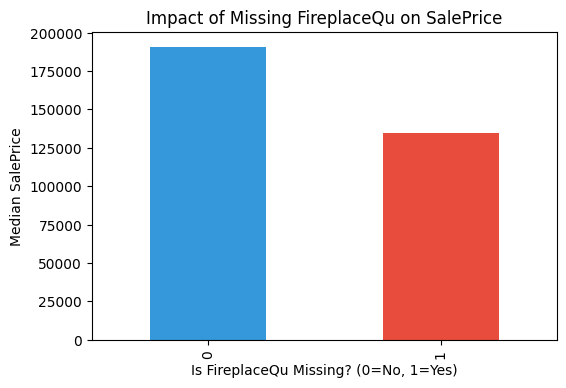

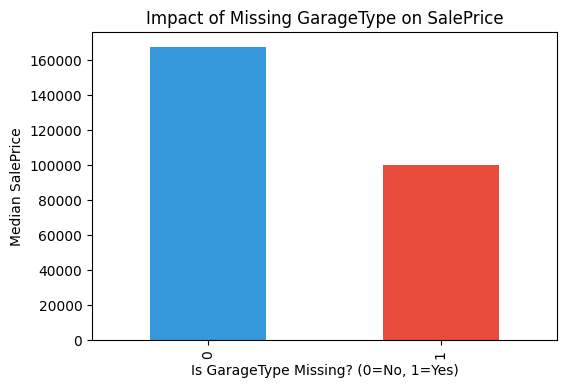

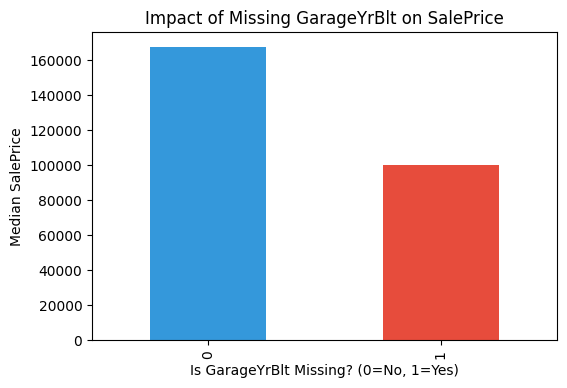

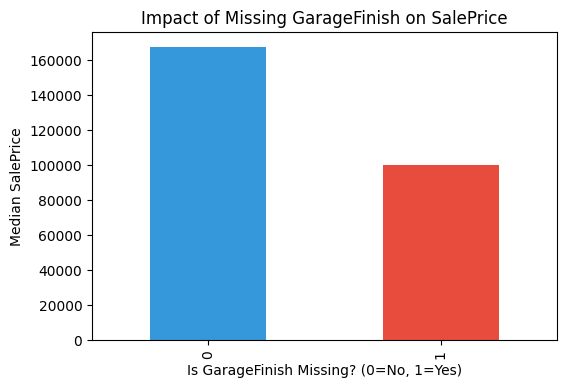

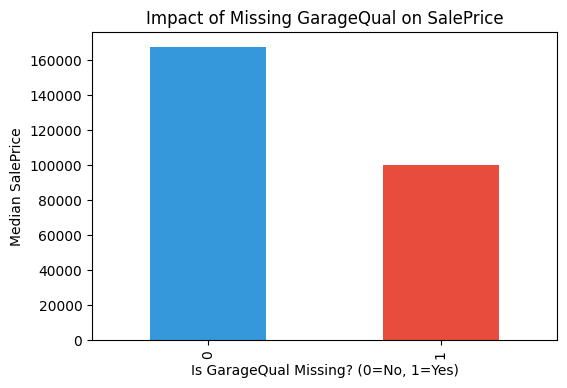

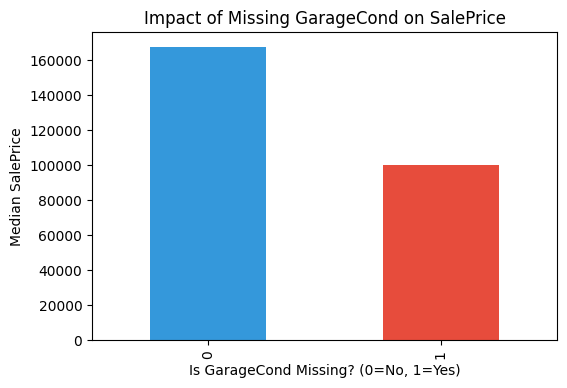

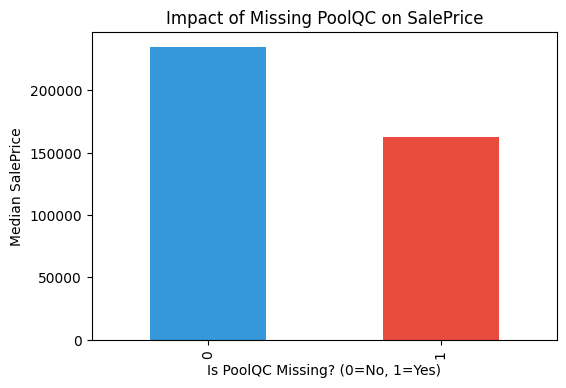

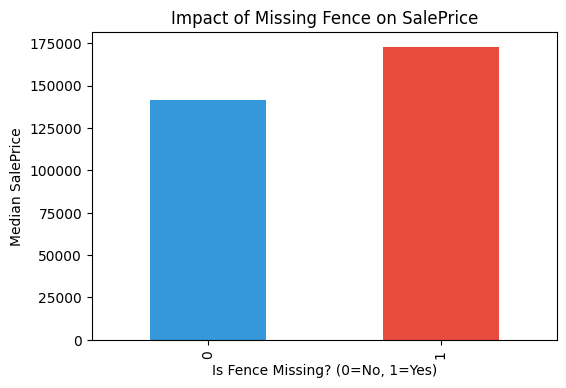

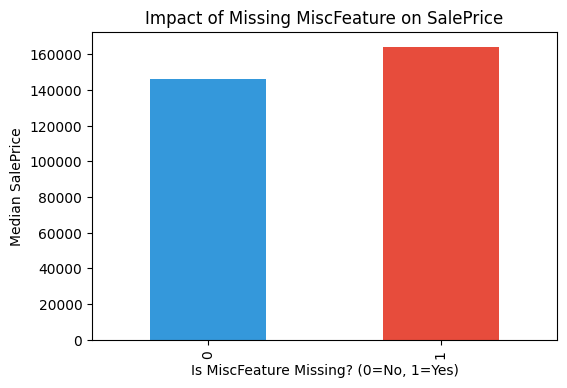

In [ ]:
# List of features with missing values
features_with_na = [f for f in train.columns if train[f].isnull().sum() > 0]

for feature in features_with_na:
    data = train.copy()
    # Create a binary variable: 1 if missing, 0 if present
    data[feature] = np.where(data[feature].isnull(), 1, 0)

    # Calculate median SalePrice for missing vs present categories
    plt.figure(figsize=(6, 4))
    data.groupby(feature)['SalePrice'].median().plot.bar(color=['#3498db', '#e74c3c'])
    plt.title(f'Impact of Missing {feature} on SalePrice')
    plt.xlabel(f'Is {feature} Missing? (0=No, 1=Yes)')
    plt.ylabel('Median SalePrice')
    plt.show()


# **Temporal (Year) Variables Analysis**

Raw year values (like 1998, 2005) are not very useful for machine learning models. What truly affects the price is the Age of the property or the time elapsed since the last remodel. We transform these features by calculating the difference between the year sold (YrSold) and the year built/remodeled. This captures the relative age of the house at the time of the transaction.

In [ ]:
# Identify temporal features
year_features = [f for f in numerical_features if 'Yr' in f or 'Year' in f]
print(f'Temporal Variables identified: {year_features}')

# Transform years into "Age" (Years since sold)
# Reasoning: We subtract the feature year from YrSold to get the age of the house/garage.
for feature in year_features:
    if feature != 'YrSold': # We keep YrSold as is, or use it only for the calculation
        train[feature] = train['YrSold'] - train[feature]
        test[feature] = test['YrSold'] - test[feature]

# Show the first few rows to verify the transformation
print("Year features converted to Age (Relative to Year Sold).")
display(train[year_features].head())


Temporal Variables identified: ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']
Year features converted to Age (Relative to Year Sold).


,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold
0,5,5,5.0,2008
1,31,31,31.0,2007
2,7,6,7.0,2008
3,91,36,8.0,2006
4,8,8,8.0,2008


In [ ]:
# Handling missing values in transformed temporal features
# Reasoning: Houses without garages or recent remodels will have NaN in these columns.
# We fill them with 0 to ensure the model can process the numerical data.

for feature in year_features:
    train[feature] = train[feature].fillna(0)
    test[feature] = test[feature].fillna(0)

print("Missing values in temporal features have been handled (filled with 0).")


Missing values in temporal features have been handled (filled with 0).


# **Data Cleaning (Outliers & Missing Values Imputation)**

# **Outlier Removal**
Extreme outliers can disproportionately influence the slope of our regression model. Based on our earlier scatter plot, we identified houses with more than 4,000 sqft of living area (GrLivArea) but very low prices. Removing these ensures the model focuses on the typical price trends of the dataset.

In [ ]:
# 1. Removing extreme outliers to improve model accuracy
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)

print(f"Outliers removed. New training set size: {len(train)}")

Outliers removed. New training set size: 1458


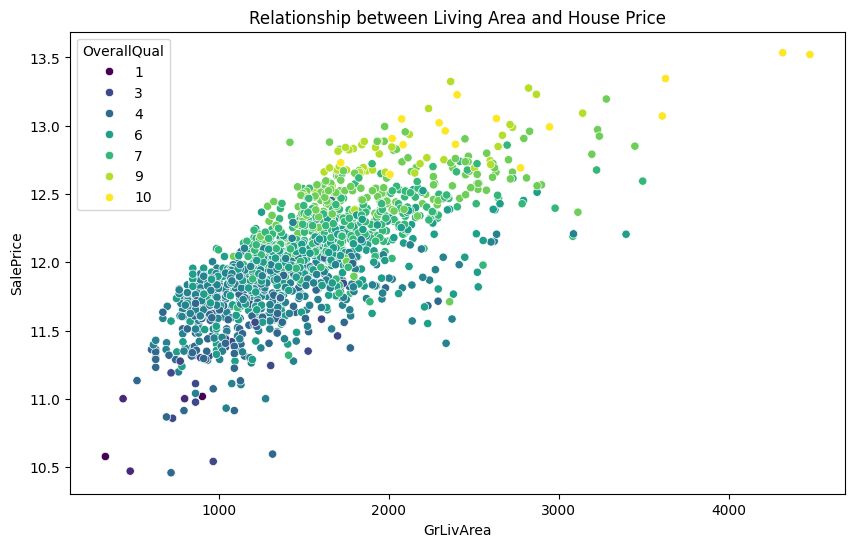

In [70]:
# Scatter Plot to detect outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis"
)
plt.title("Relationship between Living Area and House Price")
plt.show()

# Documentation for the plot:
# This plot shows the relationship between living area and house price.
# We color points based on Overall Quality, which helps us see how quality affects price.


This plot shows the relationship between living area and house price.

We color points based on **Overall Quality**, which helps us see how quality affects price

# **Target Variable Transformation**

Linear regression models assume that the error terms (residuals) are normally distributed. Our initial EDA showed that SalePrice is right-skewed. By applying a Log Transformation (np.log1p), we normalize the target variable and stabilize its variance across its range.

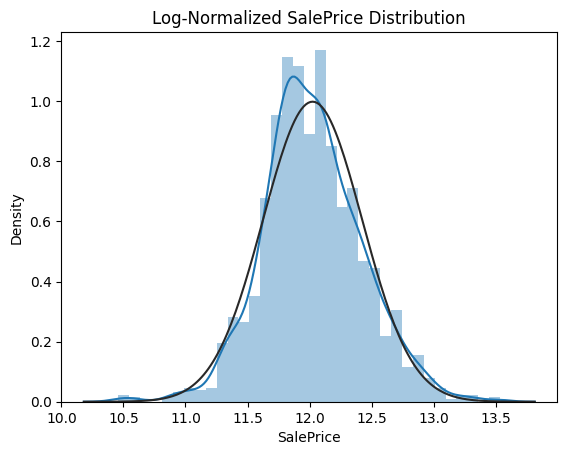

In [ ]:
# 2. Applying Log Transformation to the target variable
train["SalePrice"] = np.log1p(train["SalePrice"])

# Visualizing the result
sns.distplot(train['SalePrice'], fit=stats.norm)
plt.title('Log-Normalized SalePrice Distribution')
plt.show()


We plot the distribution of the target variable **(SalePrice)** to understand its shape.
We notice that the distribution is **right-skewed**, meaning most values are low with some very high values.

# **Missing Data Imputation**
To handle the remaining missing values, we use a dual strategy:Numerical Data: We fill missing values with the Median, which is more robust to remaining outliers than the mean.Categorical Data: We convert "NaN" into a new category called "None". This is because in this dataset, a missing value often indicates the absence of a feature (like No Pool or No Basement), which is useful information for the model.

In [ ]:
# 3. Defining a robust imputation function
def execute_imputation(df):
    # Identify numerical columns (excluding the target SalePrice)
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if col != 'SalePrice':
            df[col] = df[col].fillna(df[col].median())

    # Identify categorical columns (object and category types)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        # Fill missing values with 'None' as a new descriptive category
        df[col] = df[col].astype(object).fillna("None").astype('category')

    return df

# Applying the imputation to both Train and Test datasets
train = execute_imputation(train)
test = execute_imputation(test)

# Final verification check
print(f"Total Missing values in Train: {train.isnull().sum().sum()}")
print(f"Total Missing values in Test: {test.isnull().sum().sum()}")
print("All missing values have been successfully handled.")


Total Missing values in Train: 0
Total Missing values in Test: 0
All missing values have been successfully handled.


# **Correlation Analysis (Heatmap)**
Before finalizing our features, we use a Correlation Matrix to identify which numerical variables have the strongest linear relationship with SalePrice. This visual heatmap helps us justify why certain features (like OverallQual and GrLivArea) are crucial for our model and allows us to detect "Multicollinearity" (when independent variables are too highly correlated with each other)

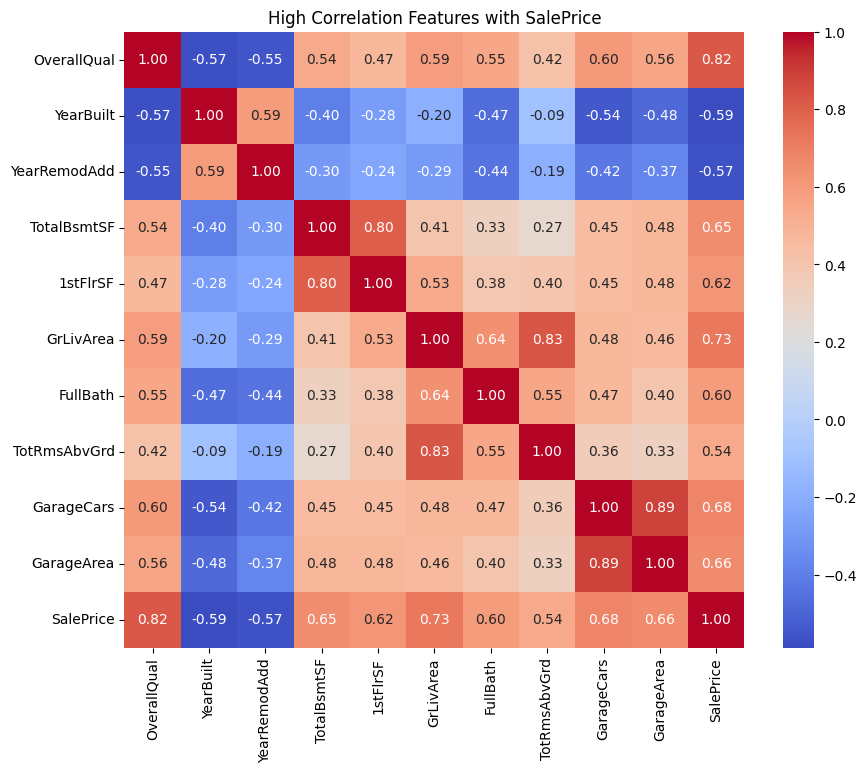

In [ ]:
# Select only numerical features for correlation analysis
numeric_df = train.select_dtypes(include=[np.number])

# Calculate correlations
corr_matrix = numeric_df.corr()

# Identify features with high correlation to SalePrice (e.g., > 0.5)
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("High Correlation Features with SalePrice")
plt.show()


We compute correlations between numerical features and the target variable.

Then we extract the top 5 features most strongly correlated with **SalePrice**.

We use a heatmap to visualize relationships between numerical variables.

This helps us quickly identify strong positive or negative correlations

# **<font color="green">Feature Engineering</font>**

# **Feature Transformation (Creating TotalSF)**

In real estate analysis, the total square footage of a house is often the most significant predictor of its price. We create a consolidated feature called TotalSF by summing the basement area (TotalBsmtSF), the first floor area (1stFlrSF), and the second floor area (2ndFlrSF). This reduces dimensionality while capturing the overall size of the property.

In [ ]:
# Creating the new feature TotalSF for both train and test sets
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']

print("Feature Transformation: 'TotalSF' created successfully.")
train[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF']].head()


Feature Transformation: 'TotalSF' created successfully.


,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


We create a new feature **(TotalSF)** that represents the total square footage of the house.

This feature is more informative than using individual floor sizes.

In [ ]:
print(f"Missing values in TotalSF (Train): {train['TotalSF'].isnull().sum()}")
print(f"Missing values in TotalSF (Test): {test['TotalSF'].isnull().sum()}")

Missing values in TotalSF (Train): 0
Missing values in TotalSF (Test): 0


# **Ordinal Encoding (Manual Ranking)**

For quality-related features, we use a manual mapping strategy instead of a generic encoder. This ensures that the mathematical order (e.g., Excellent=5 is greater than Poor=1) is strictly preserved, which is a critical requirement for house price prediction.

In [63]:
# Updated Ordinal Encoding based on manual mapping
ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond'
]

quality_map = {
    'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5
}

for col in ordinal_features:
    # 1. Fill NaNs with 'None' string
    # 2. Convert to object to avoid categorical type errors
    # 3. Map values based on the quality dictionary
    train[col] = train[col].astype(object).fillna('None').map(quality_map)
    test[col] = test[col].astype(object).fillna('None').map(quality_map)

print("✅ Ordinal features successfully mapped with quality ranks.")


✅ Ordinal features successfully mapped with quality ranks.


In [64]:
# Comprehensive map for all potential ordinal labels
full_qual_map = {
    'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5,
    'No': 1, 'Mn': 2, 'Av': 3 # Specific for BsmtExposure
}


# **One-Hot Encoding (Nominal Features)**
For nominal features like Neighborhood and BldgType, we use One-Hot Encoding with drop_first=True to avoid the "Dummy Variable Trap." We also use align to ensure that both the training and testing datasets have exactly the same column structure after transformation

In [65]:
# 1. Selection of nominal columns as per assignment
nominal_cols = ["Neighborhood", "BldgType", "LotConfig", "Foundation"]

# 2. Applying One-Hot Encoding
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test = pd.get_dummies(test, columns=nominal_cols, drop_first=True)

# 3. Essential Step: Align columns between train and test sets
# This ensures that any category missing in the test set is accounted for with 0s
train, test = train.align(test, join='left', axis=1, fill_value=0)

print(f"✅ One-Hot Encoding complete. Final feature count: {train.shape[1]}")


✅ One-Hot Encoding complete. Final feature count: 114


# **Pipeline Construction & Feature Scaling**
To finalize the preprocessing, we use a Scikit-Learn Pipeline. This ensures that the two final critical steps—Imputation (filling any missed values) and Scaling (standardizing numerical ranges)—are applied as a single, atomic operation.SimpleImputer: Acts as a safety net to fill any remaining NaNs using the median.StandardScaler: Normalizes features to have a mean of 0 and a variance of 1. This is essential for many regression algorithms (like Ridge, Lasso, or SVM) to perform optimally by ensuring no single feature dominates the model due to its scale.

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Define the Pipeline
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

def house_prices_master_pipeline(df_train, df_test):
    # Select ONLY numeric columns (this excludes 'C (all)' and any other strings)
    # This is the safest way to avoid "Cannot cast object dtype to float64"
    X_train_numeric = df_train.select_dtypes(include=[np.number]).drop('SalePrice', axis=1, errors='ignore')
    X_test_numeric = df_test.select_dtypes(include=[np.number]).drop('SalePrice', axis=1, errors='ignore')

    # Fit and transform
    X_train_final = preprocessing_pipeline.fit_transform(X_train_numeric)
    X_test_final = preprocessing_pipeline.transform(X_test_numeric)

    return X_train_final, X_test_final

# Execute
X_train_ready, X_test_ready = house_prices_master_pipeline(train, test)

print("✅ Pipeline executed successfully!")
print(f"Final features for modeling: {X_train_ready.shape[1]}")


✅ Pipeline executed successfully!
Final features for modeling: 40
